In [1]:
import numpy as np
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix

In [2]:
N = 5000 # number of birds
L = 32 # size of a box
alpha = 0.15 # rate of random change
v = 2, # speed of bird
dt = 0.1
num_iter = 800

In [3]:
def generate_positions(birds_num: int = N, box_size: int = L):
    return np.random.rand(N, 2) * L

In [4]:
def generate_orientation(birds_num: int = N):
    return np.deg2rad(np.random.rand(N) * 360)

In [5]:
def step(position: np.ndarray,
         orientation: np.ndarray,
         alpha: float,
         v: float,
         N: int,
         L: int):
    
    birds_tree = cKDTree(position,boxsize=[L,L]) 
    rows, cols = birds_tree.sparse_distance_matrix(birds_tree,max_distance=1,output_type='coo_matrix').nonzero()

    exp = np.exp(orientation*1j)
    exp_sum = np.zeros_like(exp)
    np.add.at(exp_sum, rows, exp[cols])
    
    counts = np.zeros(N)
    np.add.at(counts, rows, 1)
    counts = np.maximum(counts, 1)
    
    exp_mean = exp_sum / counts
    new_theta = np.arctan2(np.imag(exp_mean), np.real(exp_mean)) + alpha * np.random.uniform(-np.pi, np.pi, N)
    angles = np.transpose([np.cos(new_theta), np.sin(new_theta)])
    new_position = position + v * angles * dt
    new_position = new_position - L *(new_position // L)
    return new_position, new_theta

In [6]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
position = generate_positions()
orientation = generate_orientation()

In [7]:
def angle_to_colors(orientation):
    normalized = (orientation % (2 * np.pi)) / (2 * np.pi)
    return plt.cm.hsv(normalized) 

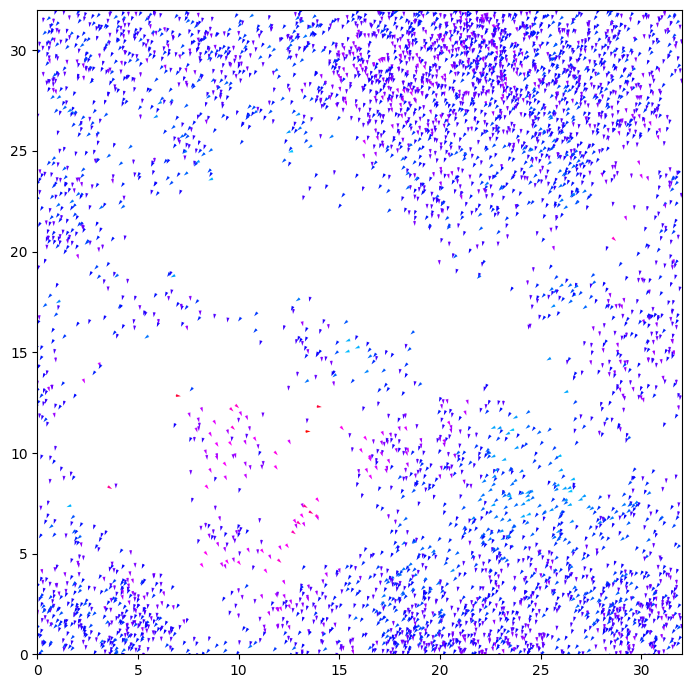

In [8]:
position = generate_positions()
orientation = generate_orientation()
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_aspect('equal')

colors = angle_to_colors(orientation)
quiver = ax.quiver(
    position[:, 0], position[:, 1],
    np.cos(orientation), np.sin(orientation),
    color=colors
)

def update(frame):
    global position, orientation
    position, orientation = step(position, orientation, alpha, v, N, L)
    colors = angle_to_colors(orientation)
    quiver.set_offsets(position)
    quiver.set_UVC(np.cos(orientation), np.sin(orientation))
    quiver.set_color(colors)   
    return quiver,

anim = animation.FuncAnimation(fig, update, frames=num_iter, interval=40, blit=True)
plt.tight_layout()
anim.save("birds.mp4", writer="ffmpeg", fps=20)
plt.show()

a=0.00  χ=0.747 ± 0.225
a=0.05  χ=0.757 ± 0.273
a=0.11  χ=0.860 ± 0.088
a=0.16  χ=0.815 ± 0.101
a=0.21  χ=0.797 ± 0.075
a=0.26  χ=0.762 ± 0.083
a=0.32  χ=0.713 ± 0.057
a=0.37  χ=0.643 ± 0.043
a=0.42  χ=0.472 ± 0.111
a=0.47  χ=0.442 ± 0.099
a=0.53  χ=0.271 ± 0.056
a=0.58  χ=0.185 ± 0.045
a=0.63  χ=0.092 ± 0.014
a=0.68  χ=0.054 ± 0.011
a=0.74  χ=0.027 ± 0.001
a=0.79  χ=0.020 ± 0.000
a=0.84  χ=0.016 ± 0.000
a=0.89  χ=0.014 ± 0.000
a=0.95  χ=0.013 ± 0.000
a=1.00  χ=0.012 ± 0.000


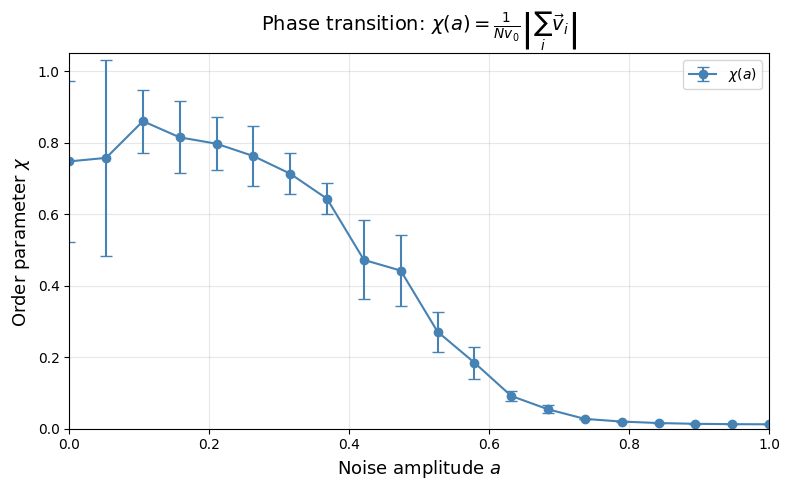

In [11]:
def compute_order_parameter(orientation: np.ndarray):
    return float(np.abs(np.mean(np.exp(1j * orientation))))

def run_trial(a: float, n_steps: int = 800, burn_in: int = 150):
    pos = generate_positions()
    ori = generate_orientation()
    chi_vals = []
    for t in range(n_steps):
        pos, ori = step(pos, ori, a, v, N, L)
        if t >= burn_in:
            chi_vals.append(compute_order_parameter(ori))
    return float(np.mean(chi_vals))

a_values = np.linspace(0.0, 1.0, 20)
repeats = 4

chi_mean = np.zeros(len(a_values))
chi_std  = np.zeros(len(a_values))

for k, a in enumerate(a_values):
    runs = [run_trial(a) for _ in range(repeats)]
    chi_mean[k] = np.mean(runs)
    chi_std[k]  = np.std(runs)
    print(f"a={a:.2f}  χ={chi_mean[k]:.3f} ± {chi_std[k]:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(a_values, chi_mean, yerr=chi_std,
            fmt="o-", capsize=4, color="steelblue", label=r"$\chi(a)$")
ax.set_xlabel("Noise amplitude $a$", fontsize=13)
ax.set_ylabel(r"Order parameter $\chi$", fontsize=13)
ax.set_title(r"Phase transition: $\chi(a) = \frac{1}{Nv_0}\left|\sum_i \vec{v}_i\right|$",
             fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("phase_transition.png", dpi=120)
plt.show()